# Sampling Methods and Central Limit Theorem

## Story 1 -- Random Sampling for a Skewed Distribution
A consumer research organization wants to understand the monthly spending behavior of households in a large city. Monthly spending is known to be right-skewed due to a small number of households spending significantly more on luxury items, while most households have modest spending habits. The researchers decide to randomly select $400$ households from the city to analyze their monthly spending.
- Generate 10,000 random values following an exponential distribution with mean 500.
- Get 400 random samples.

In [167]:
import numpy as np
import pandas as pd
import random

# Generate 10,000 random values following an exponential distribution with mean 500
mean = 500
sample_size = 10000

np.random.seed(24)
population = np.random.exponential(scale=mean, size=sample_size)

# Get 400 random samples
sample_size = 400

random.seed(24)
random_sample = random.sample(list(population), sample_size)

# Measures of center and spread
population_summary = pd.DataFrame(population).describe()
sample_summary = pd.DataFrame(random_sample).describe()
population_sample_summary = pd.concat(
    [population_summary, sample_summary],
    keys=['Population', 'Sample'],
    axis=1
)

population_sample_summary.columns = population_sample_summary.columns.droplevel(1)
population_sample_summary.T

,count,mean,std,min,25%,50%,75%,max
Population,10000.0,499.466275,500.372298,0.014755,142.317430,340.370113,696.242202,4527.682818
Sample,400.0,521.739715,504.164620,2.173935,147.202676,364.766571,738.310665,2890.163396


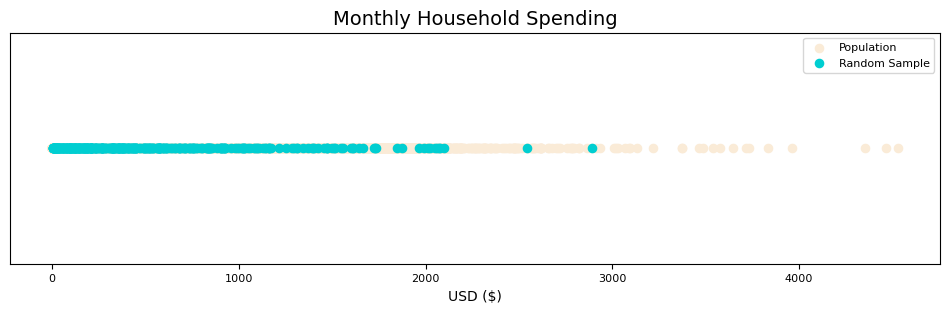

In [168]:
import matplotlib.pyplot as plt

# Plot random samples vs population 
plt.figure(figsize=(12, 3))

plt.scatter(population, [1]*len(population), color='antiquewhite', label='Population', s=35)
plt.scatter(random_sample, [1]*len(random_sample), color='darkturquoise', label='Random Sample', s=35)

plt.yticks([], visible=False)
plt.ylabel('', visible=False)
plt.xticks(fontsize='8')
plt.xlabel('USD ($)', fontsize='10')
plt.title('Monthly Household Spending', fontsize='14')
plt.legend(fontsize='8')

plt.show()

## Story 2 -- Exploring the Law of Large Numbers with Exponential Distribution
Assume an exponential distribution has a mean $\mu = \dfrac{1}{\lambda}$, where $\lambda = 2$. You will calculate the sample mean for various sample sizes and visualize how the sample mean approaches the true population mean as the sample size increases. 
-  Simulate $1000$ samples from an exponential distribution with a rate parameter $\lambda = 2$.
-  Calculate Sample Means.
-  Create a graph to show how the sample mean changes as the sample size increases, and compare it with the expected value of the exponential distribution, which is $\mu = \dfrac{1}{\lambda} = .5$.

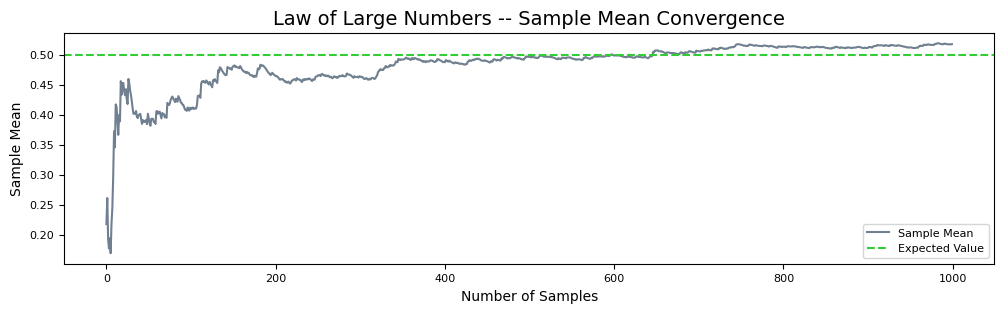

In [169]:
# Simulate 1000 samples from exponential distribution with rate parameter sigma = 2
var_lambda = 2
var_mu = 1/var_lambda
var_n = 1000

sample = np.random.exponential(scale=var_mu, size=var_n)


# Calculate sample means
sample_means = np.cumsum(sample) / np.arange(1, var_n + 1)


# Create a graph to show how the sample mean changes as the sample size increases, and
# compare it with the expected value of the exponential distribution, mu = 1/lambda = .5
plt.figure(figsize=(12, 3))

plt.plot(sample_means, label='Sample Mean', color='slategray')
plt.axhline(y=var_mu, linestyle='--', label='Expected Value', color='limegreen')

plt.xticks(fontsize='8')
plt.xlabel('Number of Samples', fontsize='10')
plt.yticks(fontsize='8')
plt.ylabel('Sample Mean', fontsize='10')
plt.title('Law of Large Numbers -- Sample Mean Convergence', fontsize='14')
plt.legend(fontsize='8')

plt.show()

## Story 3 -- Finishing a Training Module
A company tracks the completion times (in minutes) for employees finishing a mandatory training module. The times are heavily skewed, with most employees completing the module either very quickly or taking a long time.
- Generate $300$ random completion times following a beta distribution with parameters $\alpha = 2$ and $\beta = 5$ scaled to the range of $10$ to $60$ minutes.
- Take $40$ random samples, each containing $25$ completion times, and calculate the mean for each sample.
- Plot the histogram of the sample means and comment on the shape of the distribution.

In [170]:
from scipy.stats import beta

# Generate 300 random completion times following a beta distribution with parameters alpha=2 and beta=5 scaled to the range of 10-60 minutes
a = 2
b = 5
time = 60
population_size = 300

completion_times = beta.rvs(a, b, size=population_size, scale=time*2, random_state=24)

# Take 40 random samples, each containing 25 completion times, and calculate the mean for each sample
var_n = 40
size = 25

sample_means = [np.mean(np.random.choice(completion_times, size=size)) for _ in range(n)]

pd.DataFrame(sample_means).describe().T

,count,mean,std,min,25%,50%,75%,max
0,40.0,34.708262,3.614426,28.656641,31.165816,35.029152,37.163989,43.418884


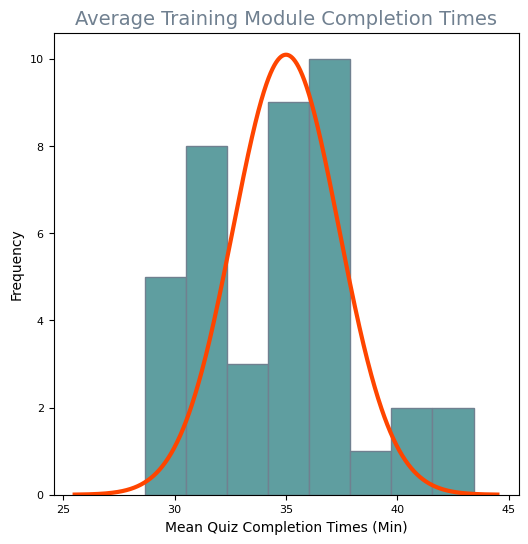

In [171]:
# Plot the histogram of the sample means and comment on the shape of the distribution
var_mu = 35
var_sigma = 15

se = lambda sigma, n: sigma / np.sqrt(n)
x = lambda mu, sigma, n: np.linspace(mu - 4*se(sigma, n), mu + 4*se(sigma, n), 1000)
sampling_distribution = lambda mu, sigma, n: (1 / (se(sigma, n) * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x(mu, sigma, n) - mu) / se(sigma, n)) ** 2) * 60

plt.figure(figsize=(6, 6))

plt.hist(sample_means, bins=8, edgecolor='slategrey', color='cadetblue')
plt.plot(x(mu, sigma, n), sampling_distribution(var_mu, var_sigma, var_n), color='orangered', linewidth=3, label='Sampling Distribution of the Sample Mean')

plt.title('Average Training Module Completion Times', color='slategrey', fontsize='14')
plt.xlabel('Mean Quiz Completion Times (Min)', fontsize='10')
plt.xticks([25, 30, 35, 40, 45], fontsize='8')
plt.ylabel('Frequency', fontsize='10')
plt.yticks(fontsize='8')

plt.show()

## Story 4 -- Central Limit Theorem with Uniform Distribution
A company is testing the weight of a large number of packaged products. The weights of these packages are uniformly distributed between $0$ and $10$ grams (i.e., each weight between $0$ and $10$ grams is equally likely). The company wants to understand how the sample mean of the product weights behaves as they take multiple random samples. The weight distribution has a mean $\mu = \dfrac{0+10}{2} = 5$ grams and variance ${\sigma}^2 = \dfrac{{(10\rightarrow0)}^2}{12} \approx 8.33$ grams${}^2$. The company will use the Central Limit Theorem (CLT) to understand how the distribution of sample means behaves as the sample size  increases. Specifically, they want to verify that as they draw larger samples, the distribution of the sample means will approach a normal distribution, even though the original distribution is uniform. 
- Simulate $1000$ samples of product weights from a uniform distribution between $0$ and $10$ grams.
- Calculate the sample mean for each sample size, from $1$ to $1000$.
- Plot the sample means and compare them with the expected mean of $5$ grams.

In [172]:
# Simulate 1000 product weight samples from a uniform distribution between 0-10 grams
sample_size = 1000
dist_min = 0
dist_max = 10

population = np.random.uniform(low=dist_min, high=dist_max, size=sample_size)

population_summary = pd.DataFrame(population).describe()
population_summary.T

,count,mean,std,min,25%,50%,75%,max
0,1000.0,4.820562,2.897154,0.007243,2.382452,4.771036,7.161703,9.989107


In [173]:
# Calculate the sample mean for each sample size, from 1-1000
sample_means = [np.mean(np.random.choice(population, size=sample_size)) for _ in range(sample_size)]

sample_means_summary = pd.DataFrame(sample_means).describe()
sample_means_summary.T

,count,mean,std,min,25%,50%,75%,max
0,1000.0,4.819181,0.090265,4.479097,4.760765,4.820384,4.878748,5.145053


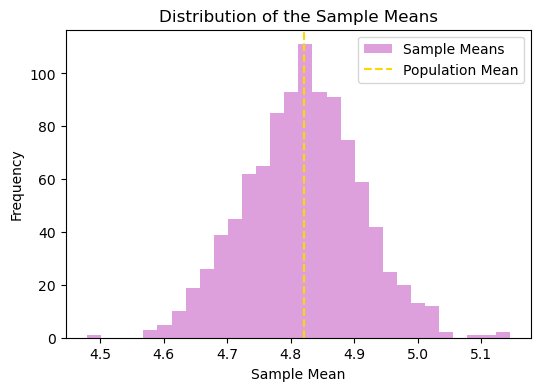

In [174]:
# Plot the sample means and compare them with the expected mean
population_mean = population_summary[0]['mean']

plt.figure(figsize=(6, 4))

plt.hist(sample_means, bins=30, color='plum', label='Sample Means')
plt.axvline(x=population_mean, color='gold', linestyle='--', label='Population Mean')

plt.title('Distribution of the Sample Means')
plt.xlabel('Sample Mean')
plt.ylabel('Frequency')

plt.legend()
plt.show()

## Story 5 -- Central Limit Theorem with Normal Distribution
A manufacturing company is analyzing the weight of products coming off their assembly line. The weights of these products are normally distributed, with a mean of $\mu = 2$ grams (indicating the target weight for the product) and a variance of ${\sigma}^2 = 1$ gram${}^2$. The company wants to understand how the average weight (the sample mean) behaves as they take multiple random samples of products from the production line. This will help them ensure that their production processes are running smoothly and that the products consistently meet the target weight.
- Simulate a normal distribution with $1000$ samples
- Calculate the sample mean for each sample size, from $1$ to $1000$
- Plot the sample means and compare them with the expected mean

## Story 6 -- Central Limit Theorem with Exponential Distribution in Customer Service
A customer service center knows the time between customer calls follows an exponential distribution. The center receives calls at an average rate of $\lambda = 1$ call per minute, so the average time between calls is $\mu = \dfrac{1}{\lambda} = 1$ minute. The distribution of the time between calls is right-skewed, with most calls coming in quickly, but occasionally, there are longer gaps between calls. The variance of this distribution is $\sigma = \dfrac{1}{{\lambda}^2} = 1$.
The customer service center wants to understand how the average waiting time (the sample mean) behaves as they take multiple random samples from the distribution of time between calls. They aim to use the Central Limit Theorem (CLT) to examine how the sample mean of call waiting times behaves as the sample size increases. The goal is to verify that as they collect larger samples, the distribution of the sample means will approach a normal distribution, even though the original distribution of time between calls is exponential. 
- Simulate an exponential distribution with $\lambda = 1$ for $1000$ samples, representing the time between customer calls.
- For each sample size (from $1$ to $1000$), calculate the sample mean of the time between calls.
- Plot the sample means and compare them with the expected mean of $1$ minute